In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import os
import sys

In [19]:
df_targets = pd.read_csv('../dataset/y_train_hCIvDMj.csv')
print(len(df_targets))

4400


<Axes: >

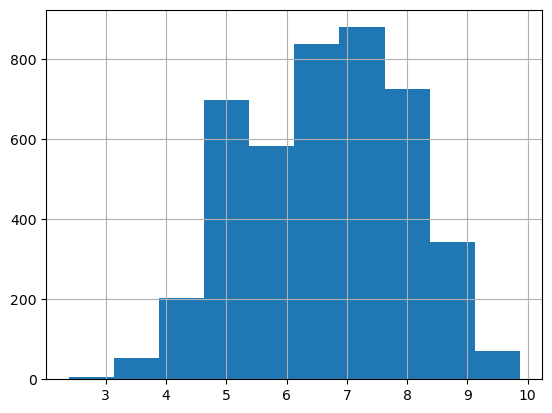

In [20]:
df_targets['y'].hist()

# Analysis of the results of the hyperparameter search

The concatenation of multiple fingerprints has given some improvement on the results, but not a lot. It seems that by making the fingerprints longer we are just adding noise to the dataset for the model.

Still, there is a good sign: the number of estimators is not hitting the end of the allowed range, which means that there is some "signal sweet spot" being hit

In [21]:
# We will load now the optimum model from the mor+rdkit+scalar paramters run:
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pIC50_predictor.model import pIC50Predictor, find_best_params, OptimizerCallback
best_mixed_model = joblib.load('../models/run_010_mor_rdk_scalars_optimum_trained.joblib')

In [22]:
best_mixed_model.model.get_params

<bound method LGBMModel.get_params of LGBMRegressor(feature_fraction=0.5, learning_rate=0.008195307829370857,
              max_depth=np.int64(21), n_estimators=np.int64(5000),
              num_leaves=np.int64(300), random_state=33, reg_lambda=0.01,
              verbose=-1)>

np.int32(29430)

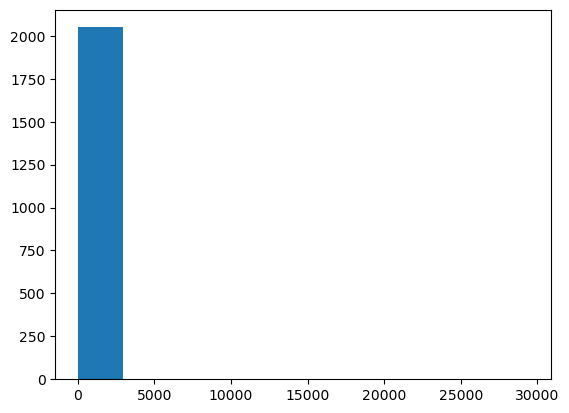

In [23]:
importances = best_mixed_model.model.feature_importances_
plt.hist(importances)
max(importances)

In [24]:
feature_importance_df = pd.DataFrame({'feature_index': range(len(importances)),'importance': importances})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

print(feature_importance_df.head(10))


   feature_index  importance
0           2049       29430
1           2048       27842
2           2052       13271
3           2051        2726
4           2050        1667
5             64        1450
6            175        1262
7            843        1252
8            184        1170
9            389        1102


In [25]:
a = pd.DataFrame({'feature_index':range(len(importances)),'importance':importances})
a.sort_values(by='importance',ascending=False)

,feature_index,importance
2049,2049,29430
2048,2048,27842
2052,2052,13271
2051,2051,2726
2050,2050,1667
...,...,...
765,765,0
1127,1127,0
22,22,0
756,756,0


In [26]:
# Now, load replicas of the morgan+rdkit+scalar fingerprint runs, get their importances and average them. Indices:13, 14, 15:
importance_ratings = []
for id in range(13,17):
    opt_model = joblib.load(f'../models/run_0{id}_mor_rdk_scalars_optimum_trained.joblib')
    imps = opt_model.model.feature_importances_
    imp_df = pd.DataFrame({'feature_index': range(len(imps)),'importance': imps})
    imp_df = imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    importance_ratings.append(imp_df)
    print(opt_model.model.get_params())


{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.007857850902864168, 'max_depth': np.int64(50), 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': np.int64(5000), 'n_jobs': None, 'num_leaves': np.int64(384), 'objective': None, 'random_state': 33, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'feature_fraction': 0.17102784504928667, 'verbose': -1}
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.007092829206171447, 'max_depth': np.int64(50), 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': np.int64(3778), 'n_jobs': None, 'num_leaves': np.int64(543), 'objective': None, 'random_state': 33, 'reg_alpha': 0.0, 'reg_lambda': 10.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0, 'feature_fractio

In [63]:
165/len(imps)
n_top_features


100

2053


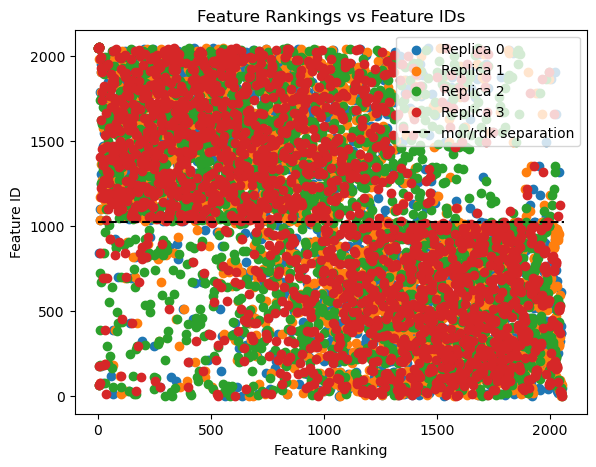

In [ ]:
n__s = len(importance_ratings[0]['feature_index'])
print(n_top_features)
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
for id in range(4):
    ax.scatter(range(n_top_features), importance_ratings[id]['feature_index'][:n_top_features], label=f'Replica {id}')
    ax.set_xlabel('Feature Ranking')
    ax.set_ylabel('Feature ID')

ax.hlines(1024,0,2060, color='black', linestyle='--', label='mor/rdk separation')
ax.legend()
ax.set_title('Feature Rankings vs Feature IDs')
f.savefig('Ranking_vs_ID.png')


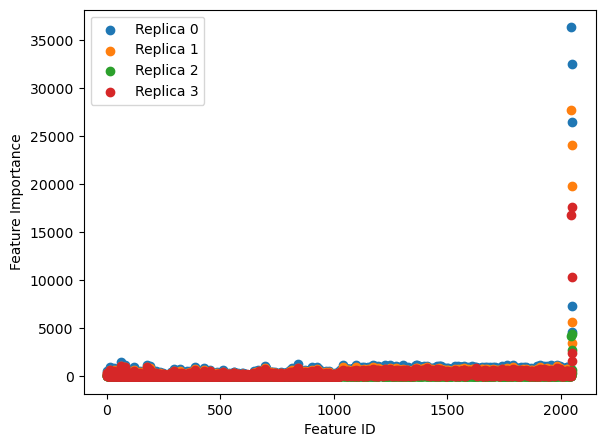

In [28]:
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
for id in range(4):
    ax.scatter(importance_ratings[id]['feature_index'][:n_top_features], importance_ratings[id]['importance'][:n_top_features], label=f'Replica {id}')
    ax.legend()
    ax.set_xlabel('Feature ID')
    ax.set_ylabel('Feature Importance')

#f.savefig('ID_vs_importance.png')


In [29]:
n_top_features = 100
# We calculate the union of the top 100 features from each model.
list_of_sets = []
for imp_dict in importance_ratings:
    top_n_f = set(imp_dict['feature_index'][:n_top_features])
    list_of_sets.append(top_n_f)

feature_union = set.union(*list_of_sets)

# Load a trained model and generate a submission

In [30]:
test_smiles_path='../dataset/X_test_0mB4D2v.csv'
model_path = '../models/run_017_mor_rdk_scalars_optimum_trained.joblib'
from pIC50_predictor.features import load_smiles_from_csv, generate_fps
from pIC50_predictor.model import pIC50Predictor 
import config 

test_x = load_smiles_from_csv(test_smiles_path)
test_features = generate_fps(
    test_x,
    fp_type=config.FP_TYPE, # ej. 'mor_rdk_scalar_pruned'
    **config.FP_PARAMS
)


predictor = pIC50Predictor.load(model_path)
predictions = predictor.predict(test_features)

Loaded the predictor from ../models/run_017_mor_rdk_scalars_optimum_trained.joblib


/home/jaime/miniconda3/envs/pic50/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [31]:
# Build the submission file in the correct format.
df_test = pd.read_csv('../'+config.DATA_PATH_TEST)
mol_ids = df_test['id']
submission_df = pd.DataFrame({'id': mol_ids, 'y': predictions})
#submission_df.to_csv('submission.csv', index=False)

In [57]:
#Get some pictures of the dataset
from rdkit import Chem
from rdkit.Chem import Draw

idx = np.random.randint(0, len(test_smiles_path), size=10)
idx

array([13,  9,  6, 10,  8, 17, 23,  7,  6, 22])

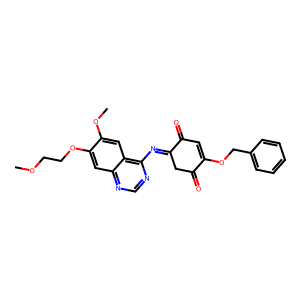

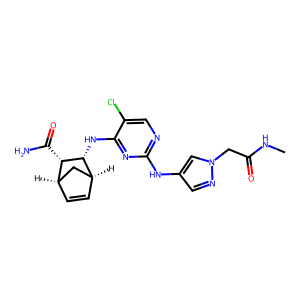

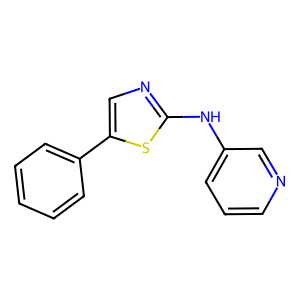

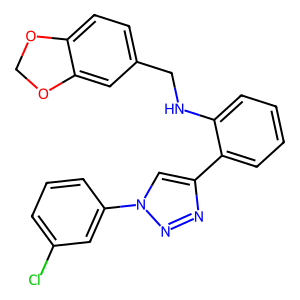

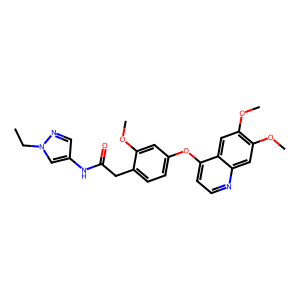

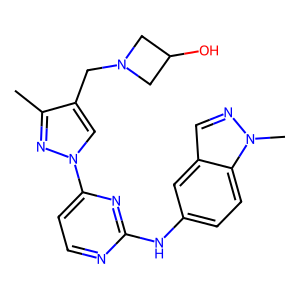

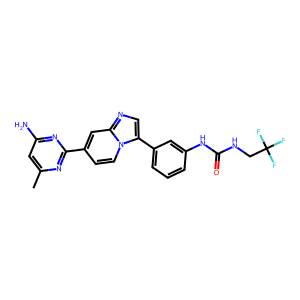

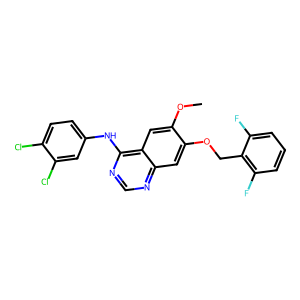

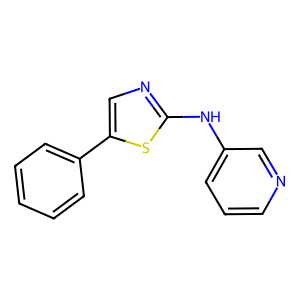

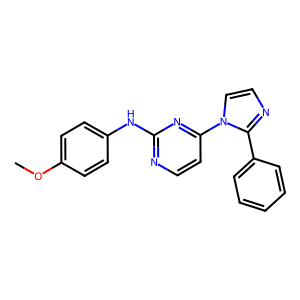

In [59]:
for i in idx:
    smiles = df_test['smiles'][i]
    mol = Chem.MolFromSmiles(smiles)
    display(Draw.MolToImage(mol))
    #drawer in svg
    drawer = Draw.MolDraw2DSVG(300,300)
    drawer.DrawMolecule(mol)
    #display the draw
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText().replace('svg:','')
    with open(f'molecule_{i}.svg','w') as f:
        f.write(svg)

In [69]:
# Graph for the slides.

n_morgan = 1024
n_rdkit = 1024

#extract the feature importances from one of the replicas
opt_model = joblib.load(f'../models/run_014_mor_rdk_scalars_optimum_trained.joblib')
imps = opt_model.model.feature_importances_


In [ ]:
imps

array([    0,   333,   147, ...,  3446,  5640, 19840],
      shape=(2053,), dtype=int32)

Text(0.5, 1.0, 'Feature Importances for Morgan+RDKit+Scalar Model')

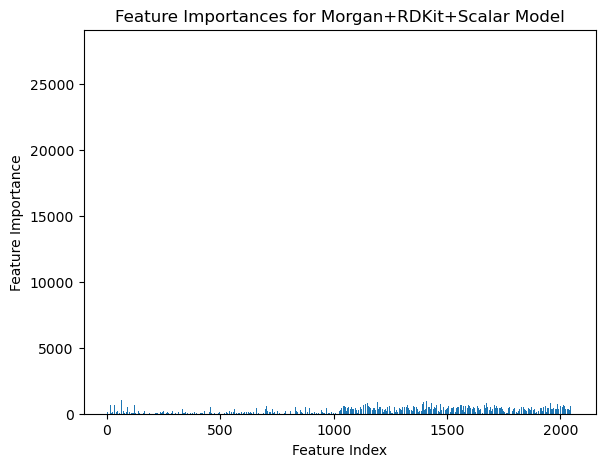

In [71]:
#plot the imps in a bar graph with as many bars as features
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
ax.bar(range(len(imps)), imps)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Feature Importance')
ax.set_title('Feature Importances for Morgan+RDKit+Scalar Model')


In [113]:
# Compute the aggregate importance of the morgan, the rdkit and the scalars.
len(importance_ratings[:])

#average the importance of each feature across the replicas, take care of the indices
feature_indices = importance_ratings[0]['feature_index']
feature_indices

result = importance_ratings[0].copy()

exit = []
for i in range(1,4):
    for feature_idx in result['feature_index']:
        result.loc[result['feature_index'] == feature_idx, 'importance'] += importance_ratings[i].loc[importance_ratings[i]['feature_index'] == feature_idx, 'importance'].values[0]

result['importance'] = result['importance']/4

In [114]:

result

,feature_index,importance
0,2048,17570.7500
1,2049,16366.7500
2,2052,11939.4375
3,2051,3178.6875
4,2050,1960.1250
...,...,...
2048,71,0.0000
2049,614,1.7500
2050,372,0.0000
2051,374,0.2500


Text(0.5, 1.0, 'Average Feature Importances for Morgan+RDKit+Scalar Model')

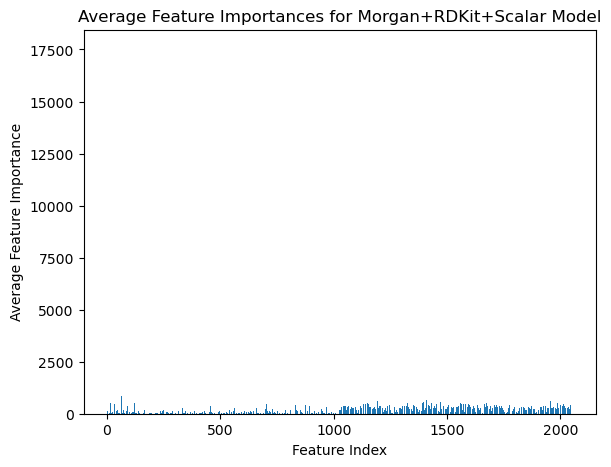

In [118]:
# barplot of the average importances
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
ax.bar(result['feature_index'], result['importance'])
ax.set_xlabel('Feature Index')
ax.set_ylabel('Average Feature Importance')
ax.set_title('Average Feature Importances for Morgan+RDKit+Scalar Model')


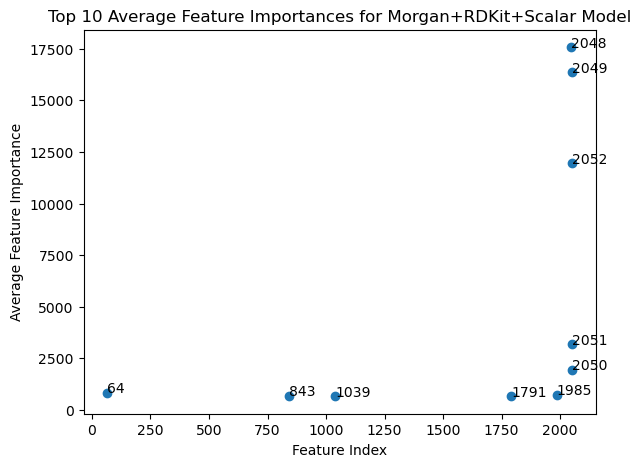

In [140]:
#Plot the top 20 feature importances as a scatter plot.
n_top = 10
result['feature_index'][:n_top]
result['importance'][:n_top]
f = plt.figure()
ax = f.add_axes((0.1,0.1,0.8,0.8))
ax.scatter(result['feature_index'][:n_top], result['importance'][:n_top])
ax.set_xlabel('Feature Index')
ax.set_ylabel('Average Feature Importance')
ax.set_title('Top 10 Average Feature Importances for Morgan+RDKit+Scalar Model')
for i in range(n_top):
    ax.text(result['feature_index'][i], result['importance'][i], str(result['feature_index'][i]))
    


In [ ]:
#accumulated importance of the morgan, rdkit and scalar features
mor_acc = result[result['feature_index'] < n_morgan]['importance'].sum()
rdk_acc = result[(result['feature_index'] >= n_morgan) & (result['feature_index'] < n_morgan + n_rdkit)]['importance'].sum()
#result[result['feature_index'] >= n_morgan + n_rdkit]['importance']#.sum()


0    17570.7500
1    16366.7500
2    11939.4375
3     3178.6875
4     1960.1250
Name: importance, dtype: float64

In [147]:
mor_acc, rdk_acc, scalar_acc

(np.float64(73303.75), np.float64(284975.125), np.float64(51015.75))